# 09 – Het definitieve model: vergelijking, foutenanalyse en conclusie

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | De modellen op alle data (`07`, `08`) naast elkaar leggen op de testset (de laatste 12 maanden), nagaan of meer data echt helpt, en onderzoeken **waar** het definitieve model zich vergist. Vooral: zijn de zwakke plekken uit de 2024-studie (feestdagen, regen) verbeterd? |
| **Input** | `models/metrics/*.json`, `models/predictions/*.parquet`, `models/data_volume.json`, `data/model_table.parquet`, `models/2024/metrics/*.json` |
| **Output** | conclusie |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

## 0. Imports en resultaten inlezen

In [1]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import citibike as cb

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
GREEN, ORANGE, INK, BLUE = "#2f6f4f", "#c47f00", "#17201b", "#3b6fb6"

table = cb.load_model_table()
metrics = {p.stem: json.loads(p.read_text(encoding="utf-8")) for p in sorted(cb.METRICS_DIR.glob("*.json"))
           if p.stem != "deployed"}
preds = {p.stem: pd.read_parquet(p) for p in sorted(cb.PRED_DIR.glob("*.parquet"))}
test = table[table["split"] == "test"]
print(f"Testperiode: {test['time'].min():%Y-%m-%d} t/m {test['time'].max():%Y-%m-%d}, {len(test):,} zone-uren, "
      f"gemiddeld {test['trips'].mean():.0f} vertrekken per zone-uur")
print("Modellen:", list(metrics))

Testperiode: 2025-10-01 t/m 2026-09-30, 262,080 zone-uren, gemiddeld 173 vertrekken per zone-uur
Modellen: ['baseline', 'hgb_one_year', 'hist_gradient_boosting', 'quick_hgb']


## 1. Overzicht
- **cv_mae**: gemiddelde MAE over de 3 backtest-folds (trainen op het verleden, valideren op het jaar erna);
- **test_***: de eenmalige meting op de laatste 12 maanden;
- **relatieve MAE**: MAE gedeeld door de gemiddelde vraag. Daarmee kunnen we voorzichtig vergelijken met de 2024-studie, die een andere testset had.

In [2]:
order = ["baseline", "hgb_one_year", "quick_hgb", "hist_gradient_boosting"]
order += [name for name in metrics if name not in order]
labels = {"baseline": "baseline (zone x uur x weekend, vorig jaar)", "hgb_one_year": "HistGB, alleen laatste jaar",
          "quick_hgb": "HistGB standaard, alle data", "hist_gradient_boosting": "HistGB getuned, alle data"}
overview = pd.DataFrame({labels.get(n, n): {"cv_mae": metrics[n].get("cv_mae_mean"), "test_mae": metrics[n]["test_mae"],
                                            "test_rmse": metrics[n]["test_rmse"], "test_r2": metrics[n]["test_r2"],
                                            "test_poisson_dev": metrics[n]["test_poisson_deviance"],
                                            "relatieve MAE": round(metrics[n]["test_mae"] / test["trips"].mean(), 3)}
                         for n in order if n in metrics}).T
m24 = json.loads((cb.METRICS_2024 / "hist_gradient_boosting.json").read_text())
t24 = cb.load_model_table(cb.DATA_2024 / "model_table.parquet")
print(f"Ter vergelijking, 2024-studie (andere testset): MAE {m24['test_mae']:.1f} bij gemiddeld "
      f"{t24.loc[t24['split'] == 'test', 'trips'].mean():.0f} vertrekken -> relatieve MAE "
      f"{m24['test_mae'] / t24.loc[t24['split'] == 'test', 'trips'].mean():.3f}")
overview

Ter vergelijking, 2024-studie (andere testset): MAE 29.0 bij gemiddeld 163 vertrekken -> relatieve MAE 0.178


,cv_mae,test_mae,test_rmse,test_r2,test_poisson_dev,relatieve MAE
"baseline (zone x uur x weekend, vorig jaar)",57.6031,70.9640,115.4286,0.6802,47.6182,0.410
"HistGB, alleen laatste jaar",NaN,30.3095,55.9832,0.9248,12.5231,0.175
"HistGB standaard, alle data",36.3663,36.0537,63.8321,0.9022,14.9121,0.208
"HistGB getuned, alle data",31.7859,28.9411,53.6342,0.9309,10.6251,0.167


**Interpretatie:**
- Het definitieve model (getuned, alle data) is het beste op elke maatstaf: **MAE 28,9, RMSE 53,6, R² 0,931**, Poisson-deviance 10,6. De baseline zit er 71 naast (R² 0,68).
- De **relatieve fout** is **16,7%** van de gemiddelde vraag (173 vertrekken per zone-uur). In de 2024-studie was dat 17,8%, op een andere testset. Voorzichtig vergeleken: iets beter, op een moeilijker testjaar (een sneeuwrijke winter, zie hieronder).
- Hetzelfde model op **alleen het laatste jaar** haalt 30,3 (17,5%). Het verschil met alle data is het effect van meer data, zie §2 en §3.

## 2. Helpt meer data? (uit `08` §4)

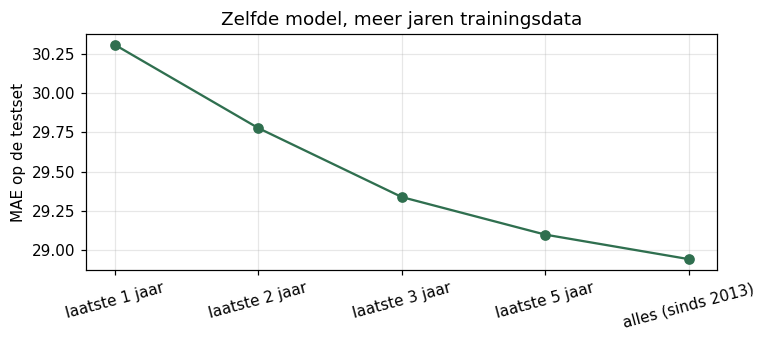

,zone-uren,mae,rmse,r2,poisson_deviance
trainingsdata,,,,,
laatste 1 jaar,262800,30.3095,55.9832,0.9248,12.5231
laatste 2 jaar,526320,29.7777,54.7821,0.9280,11.9484
laatste 3 jaar,781824,29.3374,53.9275,0.9302,11.5618
laatste 5 jaar,1278408,29.0976,53.7071,0.9308,11.1198
alles (sinds 2013),2556912,28.9411,53.6342,0.9309,10.6251


In [3]:
volume = pd.DataFrame(json.loads((cb.MODEL_DIR / "data_volume.json").read_text())).set_index("trainingsdata")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(range(len(volume)), volume["mae"], "o-", color=GREEN)
ax.set(xticks=range(len(volume)), xticklabels=volume.index, ylabel="MAE op de testset",
       title="Zelfde model, meer jaren trainingsdata")
plt.setp(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()
volume

**Interpretatie:** elke extra hoeveelheid data maakt het model beter, maar met afnemende winst: de eerste extra jaren leveren het meest op (30,3 → 29,8 → 29,3), de oudste jaren nog maar een beetje (29,1 → 28,9). Het oude netwerk (2013–2019, zonder e-bikes) lijkt minder op vandaag, maar dankzij `year` en `active_stations` kan het model er toch nog patronen uit halen (feestdagen, weer) zonder het oude niveau over te nemen.

## 3. Zijn de verschillen echt?
**a) Per backtest-fold** (zelfde folds voor alle modellen).

In [4]:
fold_table = pd.DataFrame({labels.get(n, n): metrics[n]["cv_mae"] for n in order if "cv_mae" in metrics.get(n, {})})
fold_table.index = [f"fold {i}" for i in range(len(fold_table))]
fold_table.round(2)

,"baseline (zone x uur x weekend, vorig jaar)","HistGB standaard, alle data","HistGB getuned, alle data"
fold 0,47.93,31.08,27.37
fold 1,61.25,41.22,38.50
fold 2,63.64,36.80,29.49


**b) Bootstrap per dag op de testset.** Opeenvolgende uren hangen samen, dus we hertrekken hele dagen (*block bootstrap*), 2.000 keer.

In [5]:
def paired_bootstrap(a: str, b: str, n: int = 2000, seed: int = cb.SEED):
    pa, pb = preds[a], preds[b]
    err = pd.DataFrame({"day": pa["time"].dt.normalize(), "a": (pa["trips"] - pa["pred"]).abs(),
                        "b": (pb["trips"] - pb["pred"]).abs()})
    per_day = err.groupby("day")[["a", "b"]].agg(["sum", "count"])
    sa, sb, cnt = per_day[("a", "sum")].to_numpy(), per_day[("b", "sum")].to_numpy(), per_day[("a", "count")].to_numpy()
    idx = np.random.default_rng(seed).integers(0, len(per_day), size=(n, len(per_day)))
    diff = sb[idx].sum(1) / cnt[idx].sum(1) - sa[idx].sum(1) / cnt[idx].sum(1)
    return {"MAE-winst van het definitieve model": round(float(diff.mean()), 3),
            "95%-BI": np.round(np.percentile(diff, [2.5, 97.5]), 3).tolist(), "P(beter)": round(float((diff > 0).mean()), 3)}

best = "hist_gradient_boosting"
pd.DataFrame({labels.get(o, o): paired_bootstrap(best, o) for o in order if o in preds and o != best}).T

,MAE-winst van het definitieve model,95%-BI,P(beter)
"baseline (zone x uur x weekend, vorig jaar)",42.04,"[38.516, 45.707]",1.0
"HistGB, alleen laatste jaar",1.365,"[0.663, 2.067]",1.0
"HistGB standaard, alle data",7.116,"[6.556, 7.674]",1.0


**Interpretatie:**
- **Per backtest-fold** is het getunede model beter dan het ongetunede model en de baseline, in elke fold.
- **Bootstrap per dag**: het definitieve model zit gemiddeld 42 vertrekken per uur dichter bij de werkelijkheid dan de baseline, 7,1 dichter dan het ongetunede model, en **1,4 dichter dan hetzelfde model op één jaar data** (95%-BI 0,7 tot 2,1; in alle 2.000 hertrekkingen beter). De winst van meer data is dus klein, maar echt.

## 4. Foutenanalyse van het definitieve model
### Per maand van het testjaar, naast het model dat maar één jaar data zag

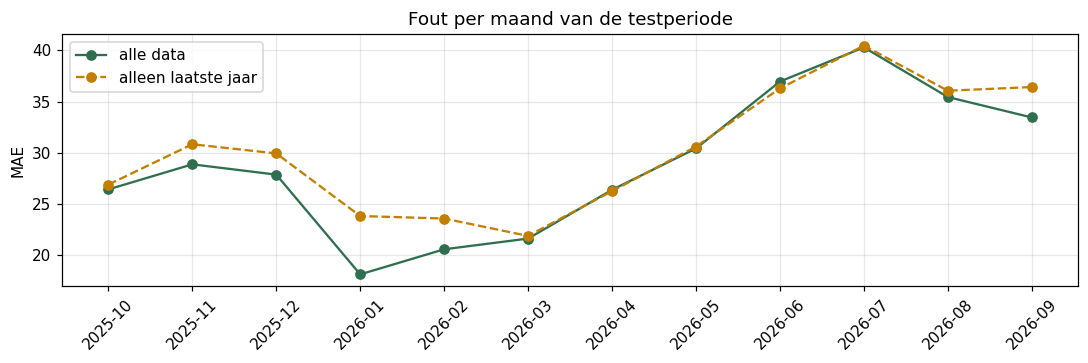

time,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
vraag,211.9,158.1,93.7,81.3,62.7,131.9,178.6,210.2,249.1,223.6,234.9,230.5
mae,26.4,28.9,27.9,18.1,20.6,21.6,26.4,30.4,37.0,40.3,35.4,33.5
mae_1_jaar,26.9,30.8,29.9,23.8,23.6,21.9,26.3,30.6,36.3,40.5,36.1,36.4


In [6]:
res = preds[best].merge(table[["zone", "time", "precipitation_mm", "temperature_c"]], on=["zone", "time"])
res["error"] = res["pred"] - res["trips"]
res["abs_error"] = res["error"].abs()
one = preds["hgb_one_year"].rename(columns={"pred": "pred_one_year"})
res = res.merge(one[["zone", "time", "pred_one_year"]], on=["zone", "time"])
res["abs_error_one_year"] = (res["pred_one_year"] - res["trips"]).abs()

monthly = res.groupby(res["time"].dt.to_period("M")).agg(vraag=("trips", "mean"), mae=("abs_error", "mean"),
                                                         mae_1_jaar=("abs_error_one_year", "mean"))
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(monthly.index.astype(str), monthly["mae"], "o-", color=GREEN, label="alle data")
ax.plot(monthly.index.astype(str), monthly["mae_1_jaar"], "o--", color=ORANGE, label="alleen laatste jaar")
ax.set(ylabel="MAE", title="Fout per maand van de testperiode")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()
monthly.round(1).T

**Interpretatie:**
- In absolute fout is de **zomer** het moeilijkst (MAE 35–40 in juni–september): daar zijn ook de meeste vertrekken. Relatief gezien is de winter niet slechter.
- Het model op alle data is in **bijna elke maand** beter dan het model op één jaar. Het grootste verschil zit in **januari en februari 2026** (18,1 tegenover 23,8 en 20,6 tegenover 23,6): de sneeuwmaanden. Wie maar één jaar data heeft, heeft weinig voorbeelden van een echte sneeuwwinter; 13 jaar bevat er meerdere (2014, 2015, 2016, 2018, 2021).

### Feestdagen: de zwakke plek uit 2024
In de 2024-studie overschatte het model Kerstmis met 213% en Thanksgiving met 165%: het had in zijn ene trainingsjaar bijna geen voorbeelden van zulke dagen. Nu heeft het er 12 jaar van gezien. Per feestdag in de testperiode: totaal aantal vertrekken, voorspelling en fout, voor beide modellen.

In [7]:
res = res.merge(table[["zone", "time", "snow_depth_cm"]], on=["zone", "time"])
daily = res.groupby(res["time"].dt.normalize()).agg(trips=("trips", "sum"), pred=("pred", "sum"),
                                                    pred_one_year=("pred_one_year", "sum"),
                                                    rain=("precipitation_mm", "mean"), sneeuw_cm=("snow_depth_cm", "max"))
daily["rain"] = daily["rain"] * 24
daily["fout %"] = ((daily["pred"] / daily["trips"] - 1) * 100).round(1)
daily["fout % (1 jaar)"] = ((daily["pred_one_year"] / daily["trips"] - 1) * 100).round(1)
holidays = cb.us_holidays(daily.index.min(), daily.index.max())
extra = [d for h in holidays for d in [h + pd.Timedelta(days=1)] if h.month == 11 and h.day >= 22]   # dag na Thanksgiving
special = daily.loc[daily.index.isin(holidays.union(pd.DatetimeIndex(extra)).union(
    pd.date_range(f"{daily.index.min().year}-12-24", f"{daily.index.min().year + 1}-01-01")))]
special[["trips", "pred", "fout %", "pred_one_year", "fout % (1 jaar)", "rain"]].round(0)

,trips,pred,fout %,pred_one_year,fout % (1 jaar),rain
time,,,,,,
2025-10-13,61079,86293.0,41.0,101407.0,66.0,41.0
2025-11-11,96690,46865.0,-52.0,35554.0,-63.0,1.0
2025-11-27,45245,47399.0,5.0,35249.0,-22.0,0.0
2025-11-28,53762,90149.0,68.0,75299.0,40.0,0.0
2025-12-24,50826,103061.0,103.0,96751.0,90.0,0.0
2025-12-25,25529,32231.0,26.0,35281.0,38.0,0.0
2025-12-26,30140,66761.0,122.0,73972.0,145.0,9.0
2025-12-27,12864,38266.0,198.0,31222.0,143.0,5.0
2025-12-28,23486,31136.0,33.0,29978.0,28.0,1.0


**Interpretatie:** de feestdagen zelf gaan nu goed:
- **Thanksgiving** (27/11): +5% (één jaar data: −22%; in de 2024-studie +165%);
- **Kerstmis** (25/12): +26% (2024-studie: +213%); **Nieuwjaar**: −4%; **Memorial Day**: +11%; **Labor Day**: −7%.

Wat nog steeds misgaat, zijn de **dagen rond de feestdagen** die geen officiële feestdag zijn: de dag na Thanksgiving (+68%), kerstavond (+103%) en de week tussen Kerstmis en Nieuwjaar (+33% tot +198%). Het model kent daar geen "vakantie" en verwacht gewone werkdagen. Ook **Veterans Day** (11/11) gaat fout, maar andersom (−52%): het model leerde dat feestdagen rustig zijn, terwijl veel New Yorkers op Veterans Day gewoon werken. Eén vlag `is_holiday` voor alle feestdagen is dus te grof.

**Mogelijke verbetering** (niet gedaan): aparte kenmerken per soort feestdag en een kenmerk "schoolvakantie / tussen Kerstmis en Nieuwjaar".

In [8]:
print("Grootste dagfouten van het definitieve model:")
daily.reindex(daily["fout %"].abs().sort_values(ascending=False).index).head(10)[
    ["trips", "pred", "fout %", "fout % (1 jaar)", "rain", "sneeuw_cm"]].round(1)

Grootste dagfouten van het definitieve model:


,trips,pred,fout %,fout % (1 jaar),rain,sneeuw_cm
time,,,,,,
2026-01-26,6058,40737.2,572.5,805.1,0.4,26.0
2026-01-25,3051,10919.6,257.9,514.8,33.8,29.0
2025-12-27,12864,38265.6,197.5,142.7,5.3,10.0
2026-02-24,13119,32950.5,151.2,344.8,0.0,51.0
2025-12-26,30140,66761.3,121.5,145.4,9.0,5.0
2025-12-24,50826,103060.7,102.8,90.4,0.0,1.0
2026-01-27,16123,29920.2,85.6,204.8,0.1,21.0
2025-12-30,49286,88267.2,79.1,70.5,0.0,0.0
2026-02-22,19029,34008.7,78.7,81.5,13.8,8.0


**Interpretatie:** de grootste dagfouten zitten in twee groepen:
- **na een sneeuwstorm** (25–27 januari 2026: 26–29 cm sneeuw; 24 februari 2026: 51 cm, de dag na de sluiting). Hier helpt de sneeuwhoogte al veel: zonder dat kenmerk werd 26 januari met +867% overschat (eerste versie van dit notebook), nu met +573%, en 27 januari ging van +211% naar +86%. Maar op de dag zelf of vlak na zware sneeuw blijft het model te optimistisch: het weet niet of de straten al geruimd zijn of het systeem gedeeltelijk dicht is;
- de **kerstvakantie** (24–31 december), zie hierboven.

### Neerslag

In [9]:
res["rain_class"] = pd.cut(res["precipitation_mm"], [-0.01, 0, 0.5, 2, 100], labels=["droog", "≤0,5 mm", "0,5–2 mm", ">2 mm"])
res.groupby("rain_class", observed=True).agg(uren=("trips", "size"), werkelijk=("trips", "mean"), voorspeld=("pred", "mean"),
                                             voorspeld_1_jaar=("pred_one_year", "mean"), mae=("abs_error", "mean"),
                                             mae_1_jaar=("abs_error_one_year", "mean")).round(2)

,uren,werkelijk,voorspeld,voorspeld_1_jaar,mae,mae_1_jaar
rain_class,,,,,,
droog,221160,177.33,174.10,174.03,26.56,27.55
"≤0,5 mm",23130,182.67,179.00,181.15,42.36,44.10
"0,5–2 mm",12180,121.57,124.50,122.67,40.43,46.50
>2 mm,5610,76.59,102.09,107.36,42.61,47.25


**Interpretatie:** bij droog weer en lichte neerslag klopt het gemiddelde bijna precies (177 tegen 174). Bij **zware regen (> 2 mm/u) overschat** het model de vraag nog steeds (102 voorspeld, 77 werkelijk), zoals in 2024. Het model op alle data doet het daar wel beter dan het model op één jaar (MAE 42,6 tegenover 47,3). Zware buien blijven zeldzaam (2% van de uren), en het weer wordt op één punt in de stad gemeten.

### Per zone en per uur

,vraag,mae,bias,relatieve_mae,name,active_stations
zone,,,,,,
28,49.74,13.19,-7.22,0.27,rond 81 St & 34 Ave,174
29,31.71,7.67,0.29,0.24,rond 36 St & 4 Ave,101
27,58.84,13.95,-7.97,0.24,rond E Fordham Rd & Webster Ave,190
17,134.68,26.89,-11.37,0.20,rond Franklin St & Dupont St,37
24,72.13,13.99,-3.70,0.19,rond Parkside Ave & Ocean Ave,98
13,162.12,30.34,7.73,0.19,rond Columbus Ave & W 72 St,29


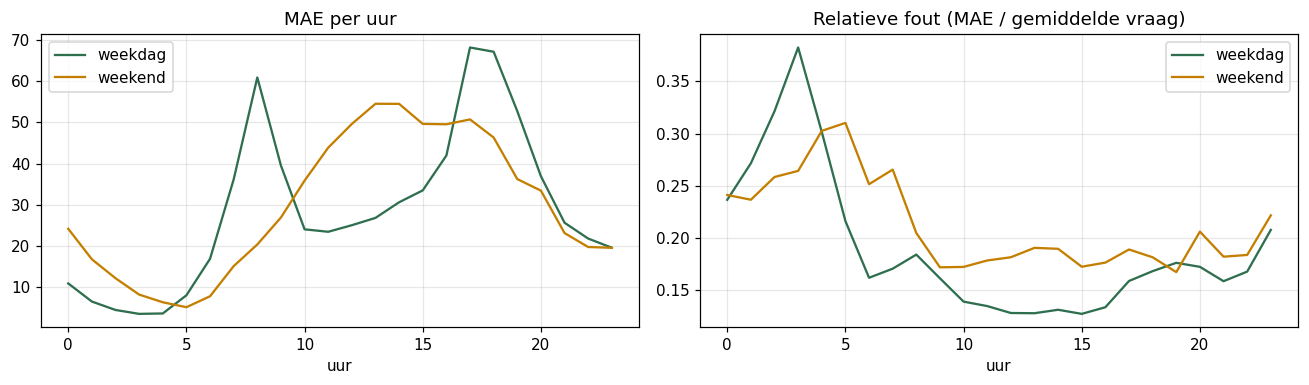

In [10]:
zones = pd.DataFrame(json.loads((cb.DATA_DIR / "zones.json").read_text(encoding="utf-8"))).set_index("zone")
by_zone = (res.groupby("zone").agg(vraag=("trips", "mean"), mae=("abs_error", "mean"), bias=("error", "mean"))
             .assign(relatieve_mae=lambda d: d["mae"] / d["vraag"]).join(zones[["name", "active_stations"]]))
display(by_zone.sort_values("relatieve_mae", ascending=False).round(2).head(6))

res["hour"], res["weekend"] = res["time"].dt.hour, res["time"].dt.dayofweek >= 5
by_hour = res.groupby(["hour", "weekend"])[["abs_error", "trips"]].mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
by_hour["abs_error"].plot(ax=axes[0], color=[GREEN, ORANGE])
axes[0].set(title="MAE per uur", xlabel="uur"); axes[0].legend(["weekdag", "weekend"])
(by_hour["abs_error"] / by_hour["trips"]).plot(ax=axes[1], color=[GREEN, ORANGE])
axes[1].set(title="Relatieve fout (MAE / gemiddelde vraag)", xlabel="uur"); axes[1].legend(["weekdag", "weekend"])
plt.tight_layout()
plt.show()

**Interpretatie:**
- **Per zone**: de grootste relatieve fout zit in de zones die het snelst **groeien**: 28 (Jackson Heights/Corona, Queens) en 27 (Fordham, de Bronx), elk met 170–190 stations, en de rustigste zone 29 (Sunset Park). In 27 en 28 **onderschat** het model de vraag (bias −7 à −8): nieuwe stations worden steeds beter gebruikt, en dat volgt het model met wat vertraging.
- **Per uur**: hetzelfde patroon als in 2024. In absolute zin zitten de grootste fouten in de spits (8u en 17–18u op weekdagen) en midden op de dag in het weekend; relatief is de nacht het moeilijkst (weinig ritten, veel toeval). Overdag is de relatieve fout op weekdagen 13–17%, in het weekend 17–19%.

## 5. Welke kenmerken zijn belangrijk? (permutation importance)
Op een steekproef van 200.000 testuren (de volledige testset is groot en het resultaat verandert er nauwelijks door).

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

params = metrics[best]["params"]
X_train, y_train, _, X_test, y_test = cb.train_test(table)
model = HistGradientBoostingRegressor(loss="poisson", categorical_features=[cb.FEATURES.index("zone")],
                                      random_state=cb.SEED, **params).fit(X_train, y_train)
sample = X_test.sample(min(200_000, len(X_test)), random_state=cb.SEED)
imp = permutation_importance(model, sample, y_test.loc[sample.index], scoring="neg_mean_absolute_error",
                             n_repeats=3, random_state=cb.SEED)
pd.Series(imp.importances_mean, index=cb.FEATURES).sort_values(ascending=False).round(3).rename("MAE-stijging")

hour                101.920
zone                 93.844
temperature_c        38.599
weekday              20.383
precipitation_mm      8.239
month                 7.070
snow_depth_cm         4.783
active_stations       4.301
is_holiday            1.818
wind_kmh              0.606
is_weekend            0.415
year                  0.000
Name: MAE-stijging, dtype: float64

**Interpretatie:**
- **Uur** en **zone** blijven veruit het belangrijkst, daarna **temperatuur** en **weekdag**, net als in 2024.
- **Sneeuwhoogte** (+4,8) en **actieve stations** (+4,3) dragen duidelijk bij.
- **`year` scoort 0**, terwijl de ablatie in `08` liet zien dat het model zonder `year` veel slechter is. Geen tegenspraak: permutation importance husselt een kolom **binnen de testset**, en daarin is het jaar bijna overal 2025 of 2026. Daartussen maakt het model weinig verschil. `year` is belangrijk om bij het **trainen** de jaren uit elkaar te houden, niet om binnen één testjaar te onderscheiden. Een goede les: permutation importance meet "wat helpt binnen deze testset", niet "wat had het model nodig om te leren".

## 6. Conclusie
**Het definitieve model** is HistGradientBoosting met Poisson-verlies, getraind op alle 13 jaar Citi Bike-data, met de kenmerken uit 2024 plus `year`, `active_stations` en `snow_depth_cm`. Het staat in de API.

| | Test-MAE | Test-R² | Relatieve MAE |
|---|---|---|---|
| baseline (vorig jaar per zone × uur × weekend) | 71,0 | 0,68 | 41% |
| HistGB, alleen laatste jaar | 30,3 | 0,925 | 17,5% |
| **HistGB getuned, alle data** | **28,9** | **0,931** | **16,7%** |

**Wat heeft "alle data" opgeleverd?**
1. Een **beter model**: 1,4 vertrekken per uur beter dan hetzelfde model op één jaar (95%-BI 0,7 tot 2,1), in bijna elke maand, en vooral in de sneeuwmaanden.
2. **Feestdagen** gaan nu goed (Thanksgiving +5%, Kerstmis +26%, tegenover +165% en +213% in de 2024-studie). Het model heeft er in de trainingsjaren 12 van elk gezien in plaats van geen.
3. Een **iteratie door de foutenanalyse**: de grootste fouten zaten na sneeuwstormen, dus kwam de sneeuwhoogte erbij (test-MAE 30,1 → 28,9).

**Echte verbetering of artefact?** De winst van meer data is klein maar robuust (bootstrap, elke maand). De winst van de sneeuwhoogte is groot op de testset maar niet zichtbaar in de backtest, omdat die jaren weinig sneeuw hadden. Ze is dus gemeten op één sneeuwrijke winter. Het mechanisme (lagere vraag zolang er sneeuw ligt) is wel logisch en zichtbaar op precies de juiste dagen.

**Wat zou nog helpen?** Kenmerken voor vakantieperiodes en per soort feestdag, weer per zone in plaats van op één punt, en informatie over de staat van het systeem (gesloten stations, geruimde straten na sneeuw).